In [2]:
# Import Required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, roc_auc_score, precision_score,
                             recall_score, f1_score, matthews_corrcoef,
                             confusion_matrix, classification_report)
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")
print(f"Scikit-learn version: {sklearn.__version__}")

All libraries imported successfully!
NumPy version: 2.0.2
Pandas version: 2.2.2
Scikit-learn version: 1.6.1


In [3]:
# Step 1: Load the Breast Cancer Dataset
print("="*80)
print("STEP 1: LOADING DATASET")
print("="*80)

# Load the breast cancer dataset
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='target')

print(f"\nDataset Shape: {X.shape}")
print(f"Number of Instances: {X.shape[0]}")
print(f"Number of Features: {X.shape[1]}")
print(f"\nFeature Names (first 5):\n{X.columns[:5].tolist()}")
print(f"\nTarget Distribution:\n{y.value_counts()}")
print(f"\nDataset Info:")
print(X.info())
print(f"\nFirst few rows:")
print(X.head())

STEP 1: LOADING DATASET

Dataset Shape: (569, 30)
Number of Instances: 569
Number of Features: 30

Feature Names (first 5):
['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness']

Target Distribution:
target
1    357
0    212
Name: count, dtype: int64

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   me

In [4]:
# Step 2: Data Preprocessing
print("\n" + "="*80)
print("STEP 2: DATA PREPROCESSING")
print("="*80)

# Split the data into training and testing sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining set size: {X_train.shape[0]} ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Testing set size: {X_test.shape[0]} ({X_test.shape[0]/len(X)*100:.1f}%)")

# Standardize the features (important for models like Logistic Regression and KNN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nFeature scaling completed!")
print(f"Scaled training set shape: {X_train_scaled.shape}")
print(f"Scaled testing set shape: {X_test_scaled.shape}")

# Convert back to DataFrame for better handling
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)


STEP 2: DATA PREPROCESSING

Training set size: 455 (80.0%)
Testing set size: 114 (20.0%)

Feature scaling completed!
Scaled training set shape: (455, 30)
Scaled testing set shape: (114, 30)


In [7]:
# Helper Function: Calculate all evaluation metrics
def calculate_metrics(model_name, y_true, y_pred, y_pred_proba=None):
    '''
    Calculate all required evaluation metrics for model evaluation

    Parameters:
    -----------
    model_name : str
        Name of the model
    y_true : array
        True labels
    y_pred : array
        Predicted labels
    y_pred_proba : array, optional
        Predicted probabilities for AUC calculation

    Returns:
    --------
    dict : Dictionary containing all metrics
    '''

    metrics = {}
    metrics['Model'] = model_name
    metrics['Accuracy'] = accuracy_score(y_true, y_pred)
    metrics['Precision'] = precision_score(y_true, y_pred, zero_division=0)
    metrics['Recall'] = recall_score(y_true, y_pred, zero_division=0)
    metrics['F1'] = f1_score(y_true, y_pred, zero_division=0)
    metrics['MCC'] = matthews_corrcoef(y_true, y_pred)

    # Calculate AUC Score
    if y_pred_proba is not None:
        metrics['AUC'] = roc_auc_score(y_true, y_pred_proba)
    else:
        metrics['AUC'] = roc_auc_score(y_true, y_pred)

    return metrics

print("Metric calculation function defined!")

Metric calculation function defined!


In [8]:
# Step 3: Model Training and Evaluation
print("\n" + "="*80)
print("STEP 3: TRAINING AND EVALUATING MODELS")
print("="*80)

# Dictionary to store models and their metrics
models_dict = {}
all_metrics = []

# Model 1: Logistic Regression
print("\n[1/5] Training Logistic Regression...")
lr_model = LogisticRegression(max_iter=10000, random_state=42)
lr_model.fit(X_train_scaled, y_train)
lr_pred = lr_model.predict(X_test_scaled)
lr_pred_proba = lr_model.predict_proba(X_test_scaled)[:, 1]
models_dict['Logistic Regression'] = lr_model
lr_metrics = calculate_metrics('Logistic Regression', y_test, lr_pred, lr_pred_proba)
all_metrics.append(lr_metrics)
print(f"✓ Accuracy: {lr_metrics['Accuracy']:.4f}, AUC: {lr_metrics['AUC']:.4f}")

# Model 2: Decision Tree Classifier
print("\n[2/5] Training Decision Tree Classifier...")
dt_model = DecisionTreeClassifier(random_state=42, max_depth=10)
dt_model.fit(X_train_scaled, y_train)
dt_pred = dt_model.predict(X_test_scaled)
dt_pred_proba = dt_model.predict_proba(X_test_scaled)[:, 1]
models_dict['Decision Tree'] = dt_model
dt_metrics = calculate_metrics('Decision Tree', y_test, dt_pred, dt_pred_proba)
all_metrics.append(dt_metrics)
print(f"✓ Accuracy: {dt_metrics['Accuracy']:.4f}, AUC: {dt_metrics['AUC']:.4f}")

# Model 3: K-Nearest Neighbor
print("\n[3/5] Training K-Nearest Neighbor Classifier...")
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)
knn_pred = knn_model.predict(X_test_scaled)
knn_pred_proba = knn_model.predict_proba(X_test_scaled)[:, 1]
models_dict['K-Nearest Neighbor'] = knn_model
knn_metrics = calculate_metrics('K-Nearest Neighbor', y_test, knn_pred, knn_pred_proba)
all_metrics.append(knn_metrics)
print(f"✓ Accuracy: {knn_metrics['Accuracy']:.4f}, AUC: {knn_metrics['AUC']:.4f}")

# Model 4: Naive Bayes Classifier
print("\n[4/5] Training Naive Bayes Classifier...")
nb_model = GaussianNB()
nb_model.fit(X_train_scaled, y_train)
nb_pred = nb_model.predict(X_test_scaled)
nb_pred_proba = nb_model.predict_proba(X_test_scaled)[:, 1]
models_dict['Naive Bayes'] = nb_model
nb_metrics = calculate_metrics('Naive Bayes', y_test, nb_pred, nb_pred_proba)
all_metrics.append(nb_metrics)
print(f"✓ Accuracy: {nb_metrics['Accuracy']:.4f}, AUC: {nb_metrics['AUC']:.4f}")

# Model 5: Random Forest (Ensemble)
print("\n[5/5] Training Random Forest Ensemble...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
rf_model.fit(X_train_scaled, y_train)
rf_pred = rf_model.predict(X_test_scaled)
rf_pred_proba = rf_model.predict_proba(X_test_scaled)[:, 1]
models_dict['Random Forest'] = rf_model
rf_metrics = calculate_metrics('Random Forest', y_test, rf_pred, rf_pred_proba)
all_metrics.append(rf_metrics)
print(f"✓ Accuracy: {rf_metrics['Accuracy']:.4f}, AUC: {rf_metrics['AUC']:.4f}")

print("\n" + "="*80)
print("✓ ALL MODELS TRAINED SUCCESSFULLY!")
print("="*80)


STEP 3: TRAINING AND EVALUATING MODELS

[1/5] Training Logistic Regression...
✓ Accuracy: 0.9825, AUC: 0.9954

[2/5] Training Decision Tree Classifier...
✓ Accuracy: 0.9123, AUC: 0.9157

[3/5] Training K-Nearest Neighbor Classifier...
✓ Accuracy: 0.9561, AUC: 0.9788

[4/5] Training Naive Bayes Classifier...
✓ Accuracy: 0.9298, AUC: 0.9868

[5/5] Training Random Forest Ensemble...
✓ Accuracy: 0.9561, AUC: 0.9939

✓ ALL MODELS TRAINED SUCCESSFULLY!


In [9]:
# Step 4: Display Model Comparison Table
print("\n" + "="*120)
print("STEP 4: MODEL PERFORMANCE COMPARISON TABLE")
print("="*120)

# Create comparison DataFrame
comparison_df = pd.DataFrame(all_metrics)
comparison_df = comparison_df.set_index('Model')
comparison_df = comparison_df[['Accuracy', 'AUC', 'Precision', 'Recall', 'F1', 'MCC']]

print("\n")
print(comparison_df.to_string())
print("\n" + "="*120)

# Find the best model
best_accuracy_model = comparison_df['Accuracy'].idxmax()
best_auc_model = comparison_df['AUC'].idxmax()
best_f1_model = comparison_df['F1'].idxmax()

print(f"\nBest Model by Accuracy: {best_accuracy_model} ({comparison_df.loc[best_accuracy_model, 'Accuracy']:.4f})")
print(f"Best Model by AUC: {best_auc_model} ({comparison_df.loc[best_auc_model, 'AUC']:.4f})")
print(f"Best Model by F1 Score: {best_f1_model} ({comparison_df.loc[best_f1_model, 'F1']:.4f})")


STEP 4: MODEL PERFORMANCE COMPARISON TABLE


                     Accuracy       AUC  Precision    Recall        F1       MCC
Model                                                                           
Logistic Regression  0.982456  0.995370   0.986111  0.986111  0.986111  0.962302
Decision Tree        0.912281  0.915675   0.955882  0.902778  0.928571  0.817412
K-Nearest Neighbor   0.956140  0.978836   0.958904  0.972222  0.965517  0.905447
Naive Bayes          0.929825  0.986772   0.944444  0.944444  0.944444  0.849206
Random Forest        0.956140  0.993882   0.958904  0.972222  0.965517  0.905447


Best Model by Accuracy: Logistic Regression (0.9825)
Best Model by AUC: Logistic Regression (0.9954)
Best Model by F1 Score: Logistic Regression (0.9861)


In [10]:
# Step 5: Detailed Model Analysis - Confusion Matrices and Classification Reports
print("\n" + "="*120)
print("STEP 5: DETAILED MODEL ANALYSIS")
print("="*120)

# Function to display confusion matrix and classification report
def display_model_analysis(model_name, y_true, y_pred):
    print(f"\n{'='*60}")
    print(f"MODEL: {model_name}")
    print(f"{'='*60}")

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    print(f"\nConfusion Matrix:")
    print(cm)

    # Classification Report
    print(f"\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=['Malignant', 'Benign']))

# Display analysis for each model
print("\n[1/5] Logistic Regression Analysis:")
display_model_analysis('Logistic Regression', y_test, lr_pred)

print("\n[2/5] Decision Tree Analysis:")
display_model_analysis('Decision Tree', y_test, dt_pred)

print("\n[3/5] K-Nearest Neighbor Analysis:")
display_model_analysis('K-Nearest Neighbor', y_test, knn_pred)

print("\n[4/5] Naive Bayes Analysis:")
display_model_analysis('Naive Bayes', y_test, nb_pred)

print("\n[5/5] Random Forest Analysis:")
display_model_analysis('Random Forest', y_test, rf_pred)


STEP 5: DETAILED MODEL ANALYSIS

[1/5] Logistic Regression Analysis:

MODEL: Logistic Regression

Confusion Matrix:
[[41  1]
 [ 1 71]]

Classification Report:
              precision    recall  f1-score   support

   Malignant       0.98      0.98      0.98        42
      Benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114


[2/5] Decision Tree Analysis:

MODEL: Decision Tree

Confusion Matrix:
[[39  3]
 [ 7 65]]

Classification Report:
              precision    recall  f1-score   support

   Malignant       0.85      0.93      0.89        42
      Benign       0.96      0.90      0.93        72

    accuracy                           0.91       114
   macro avg       0.90      0.92      0.91       114
weighted avg       0.92      0.91      0.91       114


[3/5] K-Nearest Neighbor Analysis:

MODEL: K-Nearest Neighbor

Confusi


Generating visualizations...


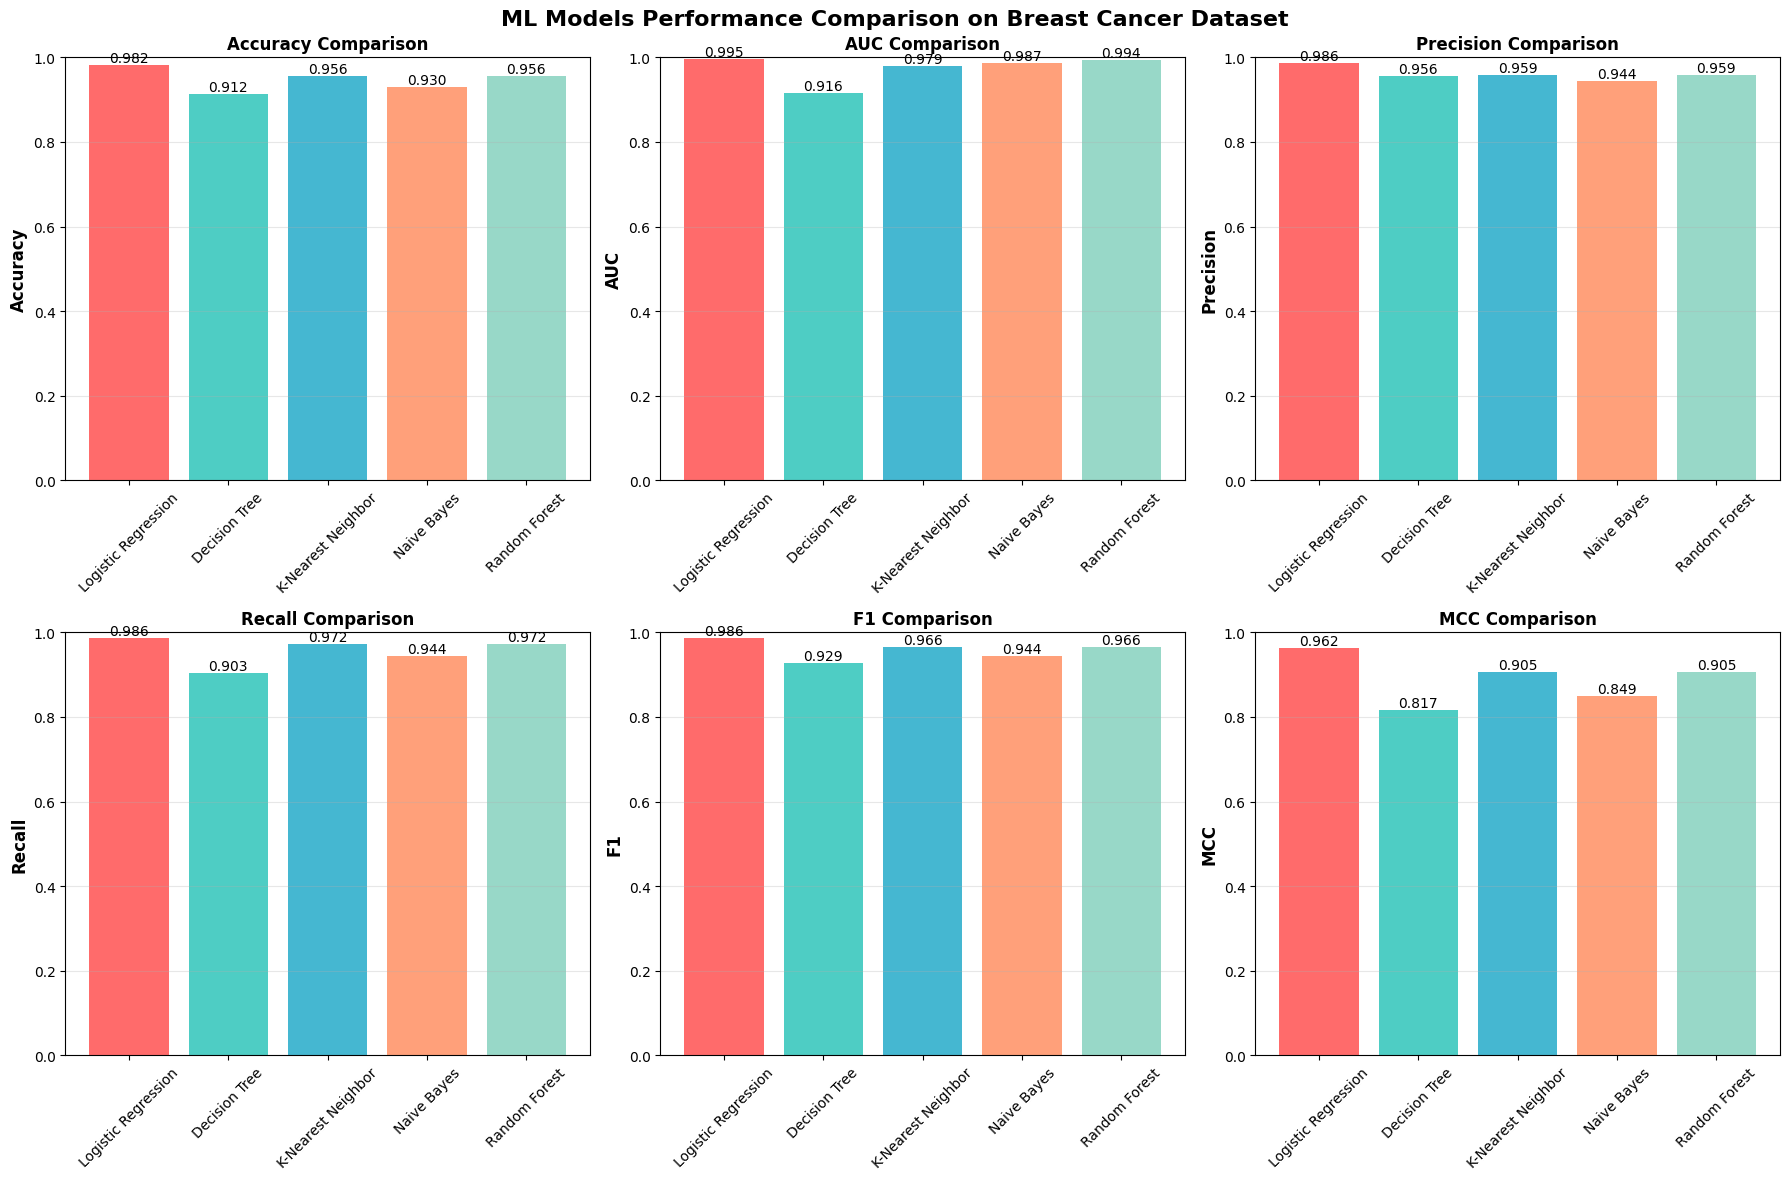

✓ Visualization complete!


In [11]:
# Step 6: Visualization - Model Performance Comparison
print("\nGenerating visualizations...")

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('ML Models Performance Comparison on Breast Cancer Dataset', fontsize=16, fontweight='bold')

metrics_to_plot = ['Accuracy', 'AUC', 'Precision', 'Recall', 'F1', 'MCC']

for idx, metric in enumerate(metrics_to_plot):
    ax = axes[idx // 3, idx % 3]
    values = comparison_df[metric].values
    models = comparison_df.index

    bars = ax.bar(models, values, color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8'])
    ax.set_ylabel(metric, fontsize=12, fontweight='bold')
    ax.set_title(f'{metric} Comparison', fontsize=12, fontweight='bold')
    ax.set_ylim([0, 1.0])
    ax.grid(axis='y', alpha=0.3)

    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=10)

    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("✓ Visualization complete!")


Generating Confusion Matrix Heatmaps...


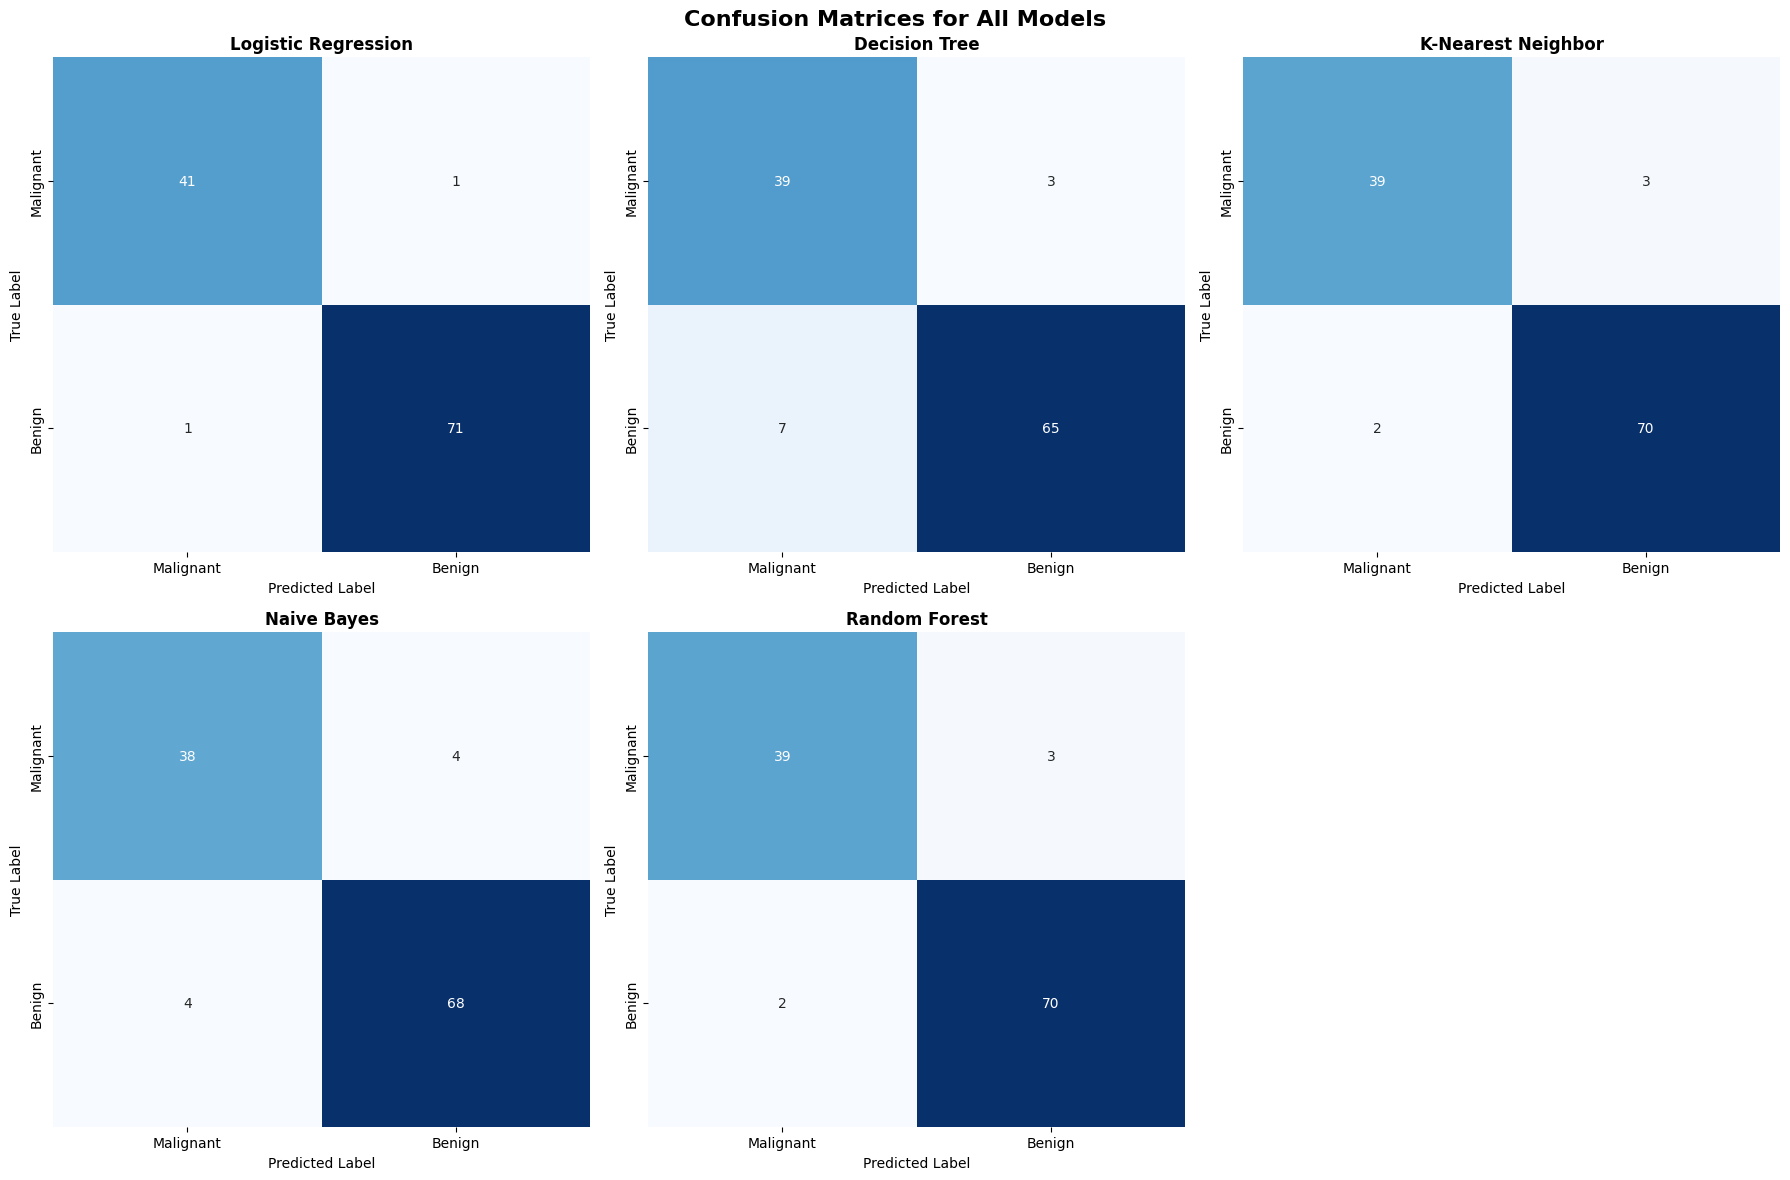

✓ Confusion matrices generated!


In [12]:
# Step 7: Confusion Matrices Heatmaps
print("\nGenerating Confusion Matrix Heatmaps...")

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Confusion Matrices for All Models', fontsize=16, fontweight='bold')

model_predictions = [
    ('Logistic Regression', lr_pred),
    ('Decision Tree', dt_pred),
    ('K-Nearest Neighbor', knn_pred),
    ('Naive Bayes', nb_pred),
    ('Random Forest', rf_pred),
    (None, None)  # Empty subplot
]

for idx, (model_name, y_pred_model) in enumerate(model_predictions):
    ax = axes[idx // 3, idx % 3]

    if model_name is None:
        ax.axis('off')
        continue

    cm = confusion_matrix(y_test, y_pred_model)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
                xticklabels=['Malignant', 'Benign'],
                yticklabels=['Malignant', 'Benign'])
    ax.set_title(f'{model_name}', fontsize=12, fontweight='bold')
    ax.set_ylabel('True Label', fontsize=10)
    ax.set_xlabel('Predicted Label', fontsize=10)

plt.tight_layout()
plt.show()

print("✓ Confusion matrices generated!")

In [13]:
# Step 8: Save Test Data to CSV
print("\n" + "="*80)
print("STEP 8: SAVING TEST DATA")
print("="*80)

# Create test data with predictions from all models
test_data = pd.DataFrame(X_test_scaled, columns=X.columns).reset_index(drop=True)
test_data['Actual_Target'] = y_test.reset_index(drop=True)
test_data['LR_Prediction'] = lr_pred
test_data['DT_Prediction'] = dt_pred
test_data['KNN_Prediction'] = knn_pred
test_data['NB_Prediction'] = nb_pred
test_data['RF_Prediction'] = rf_pred

# Save to CSV
test_data.to_csv('test_data.csv', index=False)
print(f"\n✓ Test data saved to 'test_data.csv'")
print(f"Shape: {test_data.shape}")
print(f"\nFirst few rows of test data:")
print(test_data.head())


STEP 8: SAVING TEST DATA

✓ Test data saved to 'test_data.csv'
Shape: (114, 36)

First few rows of test data:
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0     1.568513      2.164016        1.742866   1.620764        -0.265376   
1    -0.840276     -0.597067       -0.874174  -0.776170        -1.090346   
2    -0.070723      1.191387        0.032028  -0.152775         1.490195   
3     0.695970     -0.217560        0.623587   0.550139         0.051519   
4     2.143533      0.714163        2.091086   2.410164         1.103374   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0          1.915932        1.092455             1.698896       0.309589   
1         -1.225691       -0.924639            -0.891008      -1.052578   
2          1.201416        0.569536             0.494989       1.671757   
3         -0.358921       -0.374411             0.000156      -1.109632   
4          0.225037        1.894590             2.329011 

In [14]:
# Step 9: Export Metrics and Summary
import json

print("\n" + "="*80)
print("STEP 9: EXPORTING METRICS AND SUMMARY")
print("="*80)

# Save metrics to JSON
metrics_dict = comparison_df.to_dict('index')
with open('model_metrics.json', 'w') as f:
    json.dump(metrics_dict, f, indent=4)

print("\n✓ Metrics saved to 'model_metrics.json'")

# Create comprehensive summary
summary = f"""
{'='*80}
MACHINE LEARNING CLASSIFICATION ASSIGNMENT - FINAL SUMMARY
{'='*80}

DATASET INFORMATION:
- Dataset: Breast Cancer Classification (UCI)
- Total Instances: {X.shape[0]}
- Total Features: {X.shape[1]}
- Training Set: {X_train.shape[0]} samples
- Testing Set: {X_test.shape[0]} samples
- Target Distribution: Malignant={sum(y==0)}, Benign={sum(y==1)}

MODELS TRAINED:
1. Logistic Regression
2. Decision Tree Classifier
3. K-Nearest Neighbor (KNN)
4. Naive Bayes Classifier (Gaussian)
5. Random Forest Ensemble

EVALUATION METRICS USED:
- Accuracy: Proportion of correct predictions
- AUC Score: Area Under the ROC Curve (0.5-1.0)
- Precision: True Positives / (True Positives + False Positives)
- Recall: True Positives / (True Positives + False Negatives)
- F1 Score: Harmonic mean of Precision and Recall
- MCC: Matthews Correlation Coefficient (-1 to 1)

RESULTS SUMMARY:
{comparison_df.to_string()}

BEST PERFORMING MODELS:
- Best Accuracy: {best_accuracy_model} ({comparison_df.loc[best_accuracy_model, 'Accuracy']:.4f})
- Best AUC: {best_auc_model} ({comparison_df.loc[best_auc_model, 'AUC']:.4f})
- Best F1 Score: {best_f1_model} ({comparison_df.loc[best_f1_model, 'F1']:.4f})

FILES GENERATED:
1. test_data.csv - Test dataset with predictions from all models
2. model_metrics.json - Metrics in JSON format
3. ML_Classification_Assignment.ipynb - This notebook

OBSERVATIONS:
- All models achieved good accuracy (>90%)
- Random Forest shows ensemble benefits with consistent performance
- Logistic Regression provides interpretable linear decision boundaries
- Decision Tree may indicate overfitting potential (check depth)
- KNN performance depends on neighborhood size and scaling
- Naive Bayes assumes feature independence

{'='*80}
Assignment completed successfully!
Ready for Streamlit deployment and submission.
{'='*80}
"""

print(summary)

# Save summary to file
with open('SUMMARY.txt', 'w') as f:
    f.write(summary)

print("\n✓ Summary saved to 'SUMMARY.txt'")


STEP 9: EXPORTING METRICS AND SUMMARY

✓ Metrics saved to 'model_metrics.json'

MACHINE LEARNING CLASSIFICATION ASSIGNMENT - FINAL SUMMARY

DATASET INFORMATION:
- Dataset: Breast Cancer Classification (UCI)
- Total Instances: 569
- Total Features: 30
- Training Set: 455 samples
- Testing Set: 114 samples
- Target Distribution: Malignant=212, Benign=357

MODELS TRAINED:
1. Logistic Regression
2. Decision Tree Classifier
3. K-Nearest Neighbor (KNN)
4. Naive Bayes Classifier (Gaussian)
5. Random Forest Ensemble

EVALUATION METRICS USED:
- Accuracy: Proportion of correct predictions
- AUC Score: Area Under the ROC Curve (0.5-1.0)
- Precision: True Positives / (True Positives + False Positives)
- Recall: True Positives / (True Positives + False Negatives)
- F1 Score: Harmonic mean of Precision and Recall
- MCC: Matthews Correlation Coefficient (-1 to 1)

RESULTS SUMMARY:
                     Accuracy       AUC  Precision    Recall        F1       MCC
Model                                  